In [12]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [13]:
df = pd.read_csv('../../../CSV/train.csv',usecols=['Age','Fare','Survived'])

In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [15]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [16]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [17]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Check feature distributions

We use histograms (PDF shape) and QQ-plots to see how close each feature is to a normal distribution.

### Age (often close to normal)

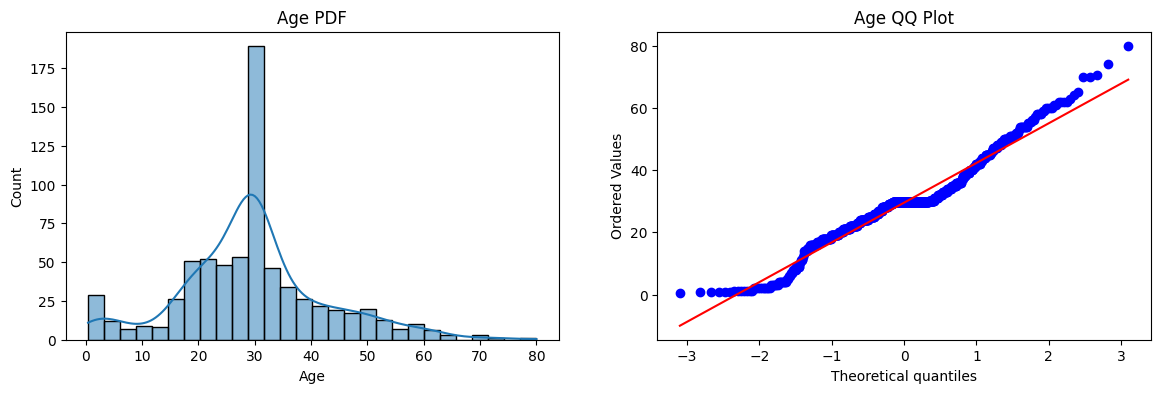

In [ ]:
# Age distribution: histogram + QQ plot
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

### Fare (typically right-skewed / non-normal)

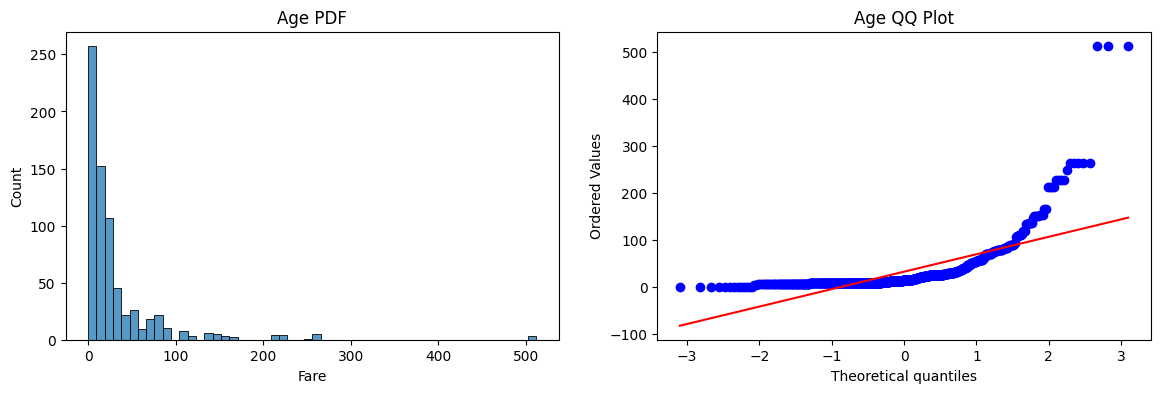

In [ ]:
# Fare distribution: often skewed, so we’ll consider transformations like log
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [ ]:
# Baseline models (before any transformation)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [ ]:
# Train and evaluate on the raw (untransformed) features
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


In [ ]:
# `FunctionTransformer` wraps an arbitrary function and makes it look like a scikit-learn transformer.
# Here we use `np.log1p(x) = log(1 + x)` which is safe for zero values (Fare can be 0).
trf = FunctionTransformer(func=np.log1p)

In [ ]:
# Fit on train, transform both train and test (no fitting on test)
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
# Re-train the same models on the transformed features and compare accuracy
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [ ]:
# Cross-validation gives a more stable estimate than a single train/test split
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6554931335830212


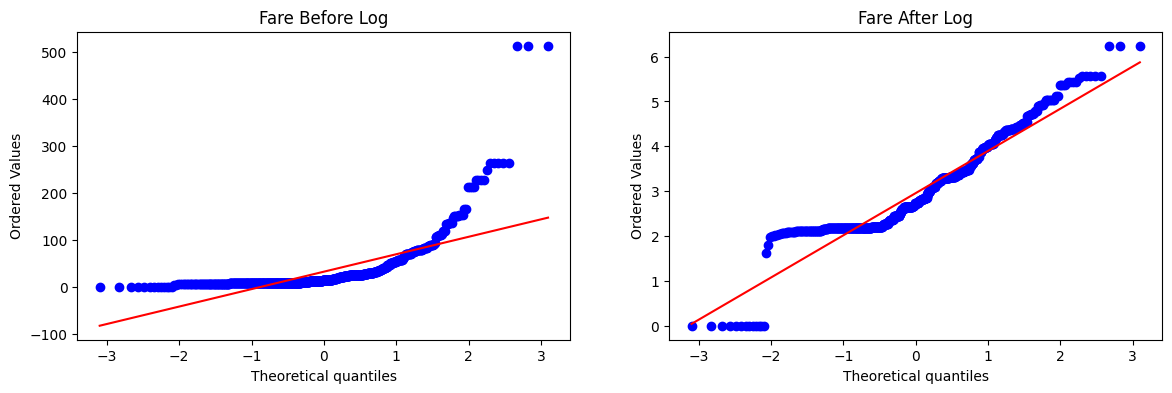

In [ ]:
# QQ-plot for Fare before vs after log-transform
plt.figure(figsize=(14, 4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
# After `FunctionTransformer`, `X_train_transformed` is still a DataFrame-like object here
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

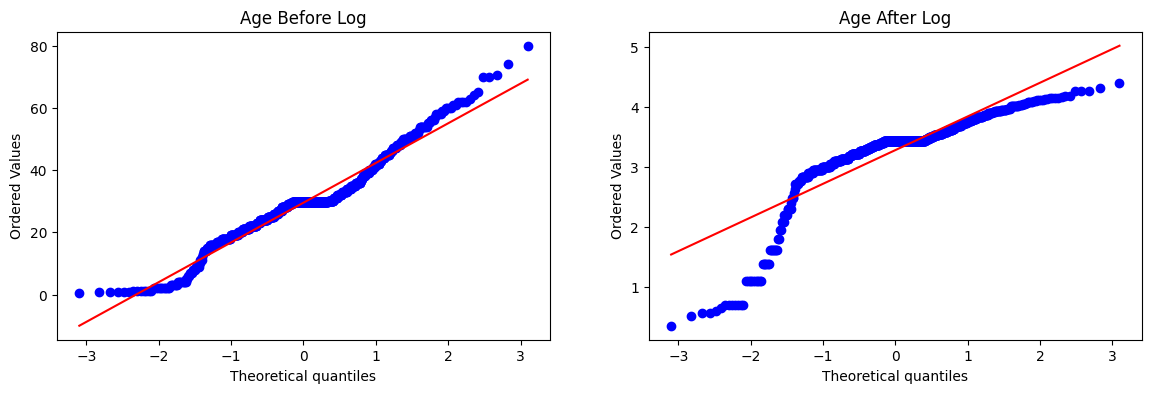

In [ ]:
# QQ-plot for Age before vs after the same log-transform (often not needed for Age)
plt.figure(figsize=(14, 4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [ ]:
# Apply a transform to a *specific column* with `ColumnTransformer`.
# Here: log-transform only Fare, pass Age through unchanged.
# Note: output is typically a NumPy array (column order: transformed Fare, then passthrough columns).
trf2 = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), ['Fare']),
], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [ ]:
# Train/evaluate again using the column-wise transform
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


In [ ]:
# Cross-validation on the column-wise transformed features
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

LR 0.6712609238451936
DT 0.6622222222222223


In [ ]:
# Helper to quickly test any 1D transform on Fare and see both accuracy + distribution effect.
def apply_transform(transform):
    """
    Apply `transform` to the Fare column using ColumnTransformer, then:
    - report 10-fold CV accuracy with Logistic Regression
    - show QQ-plots before vs after transformation
    """
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]

    # Transform only Fare; keep Age as-is
    trf = ColumnTransformer(
        [('transform', FunctionTransformer(transform), ['Fare'])],
        remainder='passthrough',
    )

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()
    print("Accuracy", np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))

    # QQ-plot: raw Fare vs transformed Fare (first column of X_trans)
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


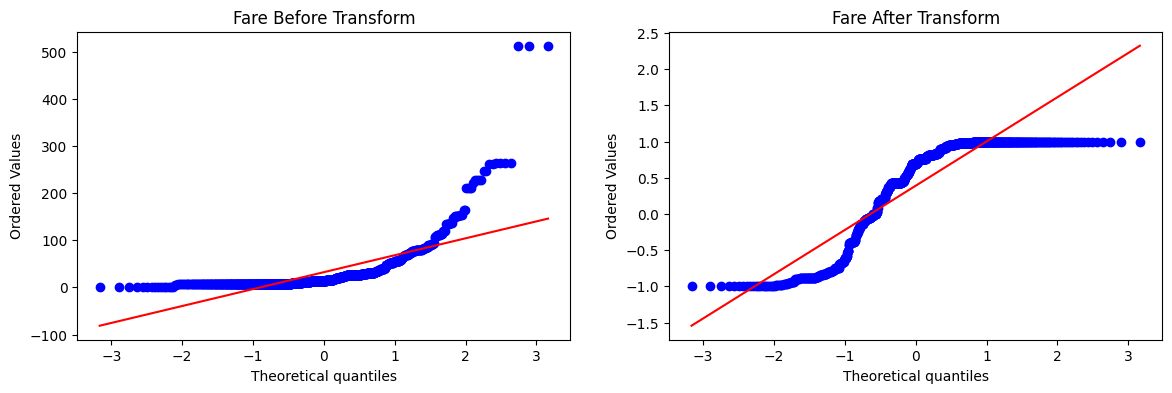

In [ ]:
# Example: try a transform function. (For normalization, `np.log1p` is more common than `np.sin`.)
apply_transform(np.sin)